* Importar y mostrar el dataframe

In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("lava18/google-play-store-apps")

print("Path to dataset files:", path)
print("Contents of the downloaded directory:")
for root, dirs, files in os.walk(path):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

Using Colab cache for faster access to the 'google-play-store-apps' dataset.
Path to dataset files: /kaggle/input/google-play-store-apps
Contents of the downloaded directory:
/kaggle/input/google-play-store-apps/googleplaystore.csv
/kaggle/input/google-play-store-apps/license.txt
/kaggle/input/google-play-store-apps/googleplaystore_user_reviews.csv


In [ ]:
import pandas as pd

csv_file_name = 'googleplaystore.csv'
csv_file_path = os.path.join(path, csv_file_name)

df = pd.read_csv(csv_file_path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


* Mostrar información sobre el dataframe

In [ ]:
print("Información de los datos")
print(f"Datos duplicados: {df.duplicated().sum()}")
print(f"Datos faltantes: \n{df.isna().sum()}")

Información de los datos
Datos duplicados: 483
Datos faltantes: 
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


In [ ]:
#Verificar outliers de rating
out_of_range_rating = df[(df['Rating'] < 1) | (df['Rating'] > 5)]
if not out_of_range_rating.empty:
    print(f"\nValores de 'Rating' fuera del rango (1-5): {len(out_of_range_rating)} filas")
    display(out_of_range_rating[['App', 'Rating']].head())
else:
    print("\nTodos los valores de 'Rating' están dentro del rango (1-5).")


Valores de 'Rating' fuera del rango (1-5): 1 filas


,App,Rating
10472,Life Made WI-Fi Touchscreen Photo Frame,19.0


In [ ]:
from numpy import nan
# Verificar outliers de type
out_of_range_type = df[(df['Type'] != "Free") & (df['Type'] != "Paid") & (df['Type'] != nan)]
if not out_of_range_type.empty:
    print(f"\nValores de 'Type' no válidos: {len(out_of_range_type)} filas")
    display(out_of_range_type[['App','Type']].head())
else:
    print("\nTodos los valores de 'Type' son válidos.")


Valores de 'Type' no válidos: 2 filas


,App,Type
9148,Command & Conquer: Rivals,NaN
10472,Life Made WI-Fi Touchscreen Photo Frame,0


In [ ]:
#Verificar outliers de Last Updated

# Intentar convertir a datetime en una copia temporal para detectar fechas inválidas
converted_dates_temp = pd.to_datetime(df['Last Updated'], errors='coerce')

# Filtrar filas donde la conversión falló (NaT)
invalid_dates = df[converted_dates_temp.isna()]

# Mostrar resultados
if not invalid_dates.empty:
    print(f"\nValores inválidos en 'Last Updated': {len(invalid_dates)} filas")
    display(invalid_dates[['App', 'Last Updated']].head())
else:
    print("\nTodos los valores de 'Last Updated' parecen ser fechas válidas.")


Valores inválidos en 'Last Updated': 1 filas


,App,Last Updated
10472,Life Made WI-Fi Touchscreen Photo Frame,1.0.19


* Creamos copia para empezar a limpiar

In [ ]:
df_clean = df.copy()

* Eliminamos datos duplicados

In [ ]:
print(f"Dataframe antes de limpiar: {df_clean.duplicated().sum()}")
df_clean = df.drop_duplicates()
print(f"Dataframe después de limpiar: {df_clean.duplicated().sum()}")

Dataframe antes de limpiar: 483
Dataframe después de limpiar: 0


* Convertirmos outliers a nan, para luego reemplazarlos

In [ ]:
df_clean.loc[(df_clean['Rating']< 1) | (df_clean['Rating'] > 5), 'Rating'] = nan

out_of_range_rating = df_clean[(df_clean['Rating'] < 1) | (df_clean['Rating'] > 5)]
if not out_of_range_rating.empty:
    print(f"\nValores de 'Rating' fuera del rango (1-5): {len(out_of_range_rating)} filas")
    display(out_of_range_rating[['App', 'Rating']].head())
else:
    print("\nTodos los valores de 'Rating' están dentro del rango (1-5).")

#print(df_clean.loc[10472])


Todos los valores de 'Rating' están dentro del rango (1-5).


In [ ]:
df_clean.loc[(df_clean['Type'] != "Free") & (df_clean['Type'] != "Paid")  & df_clean['Type'].notna(), 'Type' ] = nan

out_of_range_type = df_clean[(df_clean['Type'] != "Free") & (df_clean['Type'] != "Paid") & df_clean['Type'].notna()]
if not out_of_range_type.empty:
    print(f"\nValores de 'Type' no válidos: {len(out_of_range_type)} filas")
    display(out_of_range_type[['App','Type']].head())
else:
    print("\nTodos los valores de 'Type' son válidos.")


Todos los valores de 'Type' son válidos.


In [ ]:
# Convertir y limpiar en el DataFrame real
df_clean.loc[:, 'Last Updated'] = pd.to_datetime(
    df_clean['Last Updated'],
    errors='coerce'
)

# Detectar outliers (ya convertidos a NaT)
invalid_dates = df_clean[df_clean['Last Updated'].isna()]

# Mostrar solo los problemáticos
if invalid_dates.empty:
    print(f"\nValores de 'Last Updated' inválidos: {len(invalid_dates)} filas")
    display(invalid_dates[['App', 'Last Updated']].head())
else:
    print("\nTodos los valores de 'Last Updated' son válidos.")


Todos los valores de 'Last Updated' son válidos.


* Rellenar datos faltantes

--  Para rellenar rating, usamos el promedio de ratings y rellenamos.

In [ ]:
promedio_rating = round(df_clean['Rating'].mean(),1)
print(f"El promedio de los ratings es: {promedio_rating:.2f}")

df_clean['Rating'] = df_clean['Rating'].fillna(promedio_rating)

print(f"\nDatos faltantes después de rellenar 'Rating': \n{df_clean.isna().sum()}")

El promedio de los ratings es: 4.20

Datos faltantes después de rellenar 'Rating': 
App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              2
Price             0
Content Rating    1
Genres            0
Last Updated      1
Current Ver       8
Android Ver       3
dtype: int64


/tmp/ipykernel_3030/3083353389.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Rating'] = df_clean['Rating'].fillna(promedio_rating)


-- Para rellenar Type, tomaremos en cuenta el precio de la aplicación, si es 0 Type es 'Free', y si es mayor a 0 Type es 'Paid'.

In [ ]:
# Rellenar valores 'Type' donde son NaN
# Si 'Price' es '0', rellenar 'Type' como 'Free'
df_clean.loc[(df_clean['Type'].isna()) & (df_clean['Price'] == '0'), 'Type'] = 'Free'

# Si 'Price' no es '0', rellenar 'Type' como 'Paid'
df_clean.loc[(df_clean['Type'].isna()) & (df_clean['Price'] != '0'), 'Type'] = 'Paid'

print(f"\nDatos faltantes después de rellenar 'Type': \n{df_clean.isna().sum()}")


Datos faltantes después de rellenar 'Type': 
App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    1
Genres            0
Last Updated      1
Current Ver       8
Android Ver       3
dtype: int64


-- Para rellenar Content Rating, usamos el una función random, para seleccionar de manera aleaotoria un tipo de dato de los ya existentes.

In [ ]:
import random
# Obtener los valores que ya están
existing_content_rating_values = df_clean['Content Rating'].dropna().unique()

# Rellenar
df_clean['Content Rating'] = df_clean['Content Rating'].fillna(pd.Series(random.choices(existing_content_rating_values, k=len(df_clean)), index=df_clean.index))

print(f"Datos faltantes después de rellenar 'Content Rating': \n{df_clean.isna().sum()}")

Datos faltantes después de rellenar 'Content Rating': 
App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      1
Current Ver       8
Android Ver       3
dtype: int64


/tmp/ipykernel_3030/3248221548.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Content Rating'] = df_clean['Content Rating'].fillna(pd.Series(random.choices(existing_content_rating_values, k=len(df_clean)), index=df_clean.index))


-- Para rellenar Last Update, usamos la fecha actual

In [ ]:
from datetime import datetime

current_date_str = datetime.now().strftime('%Y-%m-%d')

df_clean.loc[(df_clean['Last Updated'].isna()), 'Last Updated'] = current_date_str

print(f"\nDatos faltantes después de rellenar 'Current Ver': \n{df_clean.isna().sum()}")


Datos faltantes después de rellenar 'Current Ver': 
App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       8
Android Ver       3
dtype: int64


-- Para rellenar Current Ver, damos un valor genérico ya existente 'Varies with device'

In [ ]:
df_clean.loc[(df_clean['Current Ver'].isna()), 'Current Ver'] = 'Varies with device'

print(f"\nDatos faltantes después de rellenar 'Current Ver': \n{df_clean.isna().sum()}")


Datos faltantes después de rellenar 'Current Ver': 
App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       3
dtype: int64


-- Para rellenar Android Ver, damos un valor genérico ya existente '4.0 and up'



In [ ]:
df_clean.loc[(df_clean['Android Ver'].isna()), 'Android Ver'] = '4.0 and up'

print(f"\nDatos faltantes después de rellenar 'Android Ver': \n{df_clean.isna().sum()}")


Datos faltantes después de rellenar 'Android Ver': 
App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64


- Transformaciones

In [ ]:
print(df_clean.loc[10472])
df_clean.drop(index = 10472, inplace = True)

App               Life Made WI-Fi Touchscreen Photo Frame
Category                                              1.9
Rating                                                4.2
Reviews                                              3.0M
Size                                               1,000+
Installs                                             Free
Type                                                 Paid
Price                                            Everyone
Content Rating                               Everyone 10+
Genres                                  February 11, 2018
Last Updated                                   2026-06-12
Current Ver                                    4.0 and up
Android Ver                                    4.0 and up
Name: 10472, dtype: object


/tmp/ipykernel_3030/852326978.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.drop(index = 10472, inplace = True)


In [ ]:
# Limpiar y convertir 'Installs' a float
df_clean['Installs'] = (
    df_clean['Installs']
    .astype(str)
    .str.replace(r'[^0-9]', '', regex=True)   # elimina TODO lo que no sea número
    .pipe(pd.to_numeric)     # convierte a número
    .astype('float64')                        # asegura float
)

# Verificación
print(df_clean[['Installs']].head())
print(f"El tipo de la columna 'Installs' es: {df_clean['Installs'].dtype}")

     Installs
0     10000.0
1    500000.0
2   5000000.0
3  50000000.0
4    100000.0
El tipo de la columna 'Installs' es: float64


/tmp/ipykernel_3030/638241193.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Installs'] = (


In [ ]:
# Limpiar y convertir 'Price' a float
df_clean['Price'] = (
    df_clean['Price']
    .astype(str)
    .str.replace(r'[^0-9.]', '', regex=True)  # deja solo números y punto decimal
    .pipe(pd.to_numeric)     # convierte a número
    .astype('float64')                        # asegura float
)

# Verificación
print(df_clean[['Price']].sample(5))
print(f"El tipo de la columna 'Price' es: {df_clean['Price'].dtype}")

      Price
9365    0.0
1287    0.0
8424    0.0
1951    0.0
4093    0.0
El tipo de la columna 'Price' es: float64


/tmp/ipykernel_3030/3433542061.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Price'] = (


In [ ]:
# Limpiar y convertir la columna 'Size' a formato numérico
def clean_size(size):
    if pd.isna(size) or size == 'Varies with device':
        return None
    size = str(size).strip() # Eliminar espacios en blanco
    size = size.replace(',', '') # Eliminar comas, e.g., '1,000+'

    if size.endswith('M'):
        return float(size.replace('M', '')) * 1000000
    elif size.endswith('k'):
        return float(size.replace('k', '')) * 1000
    elif size.endswith('+'): # e.g., '1000+'
        return float(size.replace('+', ''))
    try:
        return float(size)
    except ValueError:
        return None # Retorna None si no se puede convertir por otras razones

# 1. Aplicar la función clean_size, creando una serie temporal.
temp_size_series = df_clean['Size'].apply(clean_size)

# 2. Convertir a tipo numérico, coercing errors (None se convierte a NaN).
temp_size_series = pd.to_numeric(temp_size_series, errors='coerce')

# 3. Calcular la mediana.
median_size = temp_size_series.median()

# 4. Rellenar los valores NaN con la mediana.
temp_size_series = temp_size_series.fillna(median_size)

# 5. Asignar la serie completamente procesada de nuevo a la columna 'Size' del DataFrame,
#    y luego forzar explícitamente el tipo a float64 en la columna del DataFrame.
df_clean['Size'] = temp_size_series

df_clean['Size'] = df_clean['Size'].astype('float64')

print(f"El tipo de la columna 'Size' después de la transformación es: {df_clean['Size'].dtype}")
print("Primeras 5 filas de 'Size' después de la transformación:")
print(df_clean['Size'].head())

El tipo de la columna 'Size' después de la transformación es: float64
Primeras 5 filas de 'Size' después de la transformación:
0    19000000.0
1    14000000.0
2     8700000.0
3    25000000.0
4     2800000.0
Name: Size, dtype: float64


/tmp/ipykernel_3030/3632766395.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Size'] = temp_size_series
/tmp/ipykernel_3030/3632766395.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Size'] = df_clean['Size'].astype('float64')


In [ ]:
df_clean['Reviews'] = (
    df_clean['Reviews']
    .astype(str)
    .str.strip()                              # eliminar espacios invisibles
    .replace('', '0')                         # strings vacíos → 0
    .str.replace(r'[^0-9]', '', regex=True)   # solo números
    .pipe(pd.to_numeric)     # a número
)

# Forzar tipo al final (MUY IMPORTANTE)
df_clean['Reviews'] = df_clean['Reviews'].astype('float64')

# Verificación
print(df_clean[['Reviews']].head())
print(f"El tipo de la columna 'Reviews' es: {df_clean['Reviews'].dtype}")

    Reviews
0     159.0
1     967.0
2   87510.0
3  215644.0
4     967.0
El tipo de la columna 'Reviews' es: float64


/tmp/ipykernel_3030/1169961794.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Reviews'] = (
/tmp/ipykernel_3030/1169961794.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Reviews'] = df_clean['Reviews'].astype('float64')


In [ ]:
from datetime import datetime

#Convertir la columna 'Last Updated' en datetime
converted_dates = pd.to_datetime(df_clean['Last Updated'], format='mixed')

df_clean['Last Updated'] = converted_dates

#Verificar que la columna haya cambiado
print(f"Dtype of 'Last Updated' after conversion: {df_clean['Last Updated'].dtype}")

#Obtener dia actual, para el calculo de dias
current_date_ts = pd.Timestamp(datetime.now().date())

#Calcular la cantidad de dias desde la ultima actualizacion
df_clean.loc[:, 'Days Last Update'] = (current_date_ts - df_clean['Last Updated']).dt.days

print(df_clean[['Last Updated', 'Days Last Update']].head())
print(f"El tipo de la columna 'Days Last Update' es: {df_clean['Days Last Update'].dtype}")

/tmp/ipykernel_3030/2668994132.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Last Updated'] = converted_dates


Dtype of 'Last Updated' after conversion: datetime64[ns]
  Last Updated  Days Last Update
0   2018-01-07              3078
1   2018-01-15              3070
2   2018-08-01              2872
3   2018-06-08              2926
4   2018-06-20              2914
El tipo de la columna 'Days Last Update' es: int64


/tmp/ipykernel_3030/2668994132.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.loc[:, 'Days Last Update'] = (current_date_ts - df_clean['Last Updated']).dt.days


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10357 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   App               10357 non-null  object        
 1   Category          10357 non-null  object        
 2   Rating            10357 non-null  float64       
 3   Reviews           10357 non-null  float64       
 4   Size              10357 non-null  float64       
 5   Installs          10357 non-null  float64       
 6   Type              10357 non-null  object        
 7   Price             10357 non-null  float64       
 8   Content Rating    10357 non-null  object        
 9   Genres            10357 non-null  object        
 10  Last Updated      10357 non-null  datetime64[ns]
 11  Current Ver       10357 non-null  object        
 12  Android Ver       10357 non-null  object        
 13  Days Last Update  10357 non-null  int64         
dtypes: datetime64[ns](1), float

* Pipeline

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Definir las columnas numéricas y categóricas para el ColumnTransformer
numeric_features = ['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Days Last Update']
categorical_features = ['Category', 'Type', 'Content Rating', 'Genres', 'Current Ver', 'Android Ver']

# Crear el ColumnTransformer
pipeline = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# Aplicar las transformaciones a X
X_transf = pipeline.fit_transform(df_clean.drop(['App', 'Last Updated'], axis=1)) # Excluir 'App' y 'Last Updated'
print("Forma de X_transf:", X_transf.shape)
print("Primeros elementos de X_transf (representación sparse):")
print(X_transf[:2])

Forma de X_transf: (10357, 3030)
Primeros elementos de X_transf (representación sparse):
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 24 stored elements and shape (2, 3030)>
  Coords	Values
  (0, 0)	-0.1851009037091209
  (0, 1)	-0.15046296898474376
  (0, 2)	-0.05074846506919142
  (0, 3)	-0.17632753190442066
  (0, 4)	-0.06332538377467443
  (0, 5)	-0.13448629262311967
  (0, 6)	1.0
  (0, 39)	1.0
  (0, 42)	1.0
  (0, 56)	1.0
  (0, 284)	1.0
  (0, 3012)	1.0
  (1, 0)	-0.598311391846927
  (1, 1)	-0.1501633376991226
  (1, 2)	-0.2886320709327555
  (1, 3)	-0.17022052315893652
  (1, 4)	-0.06332538377467443
  (1, 5)	-0.15455609706103032
  (1, 6)	1.0
  (1, 39)	1.0
  (1, 42)	1.0
  (1, 59)	1.0
  (1, 1184)	1.0
  (1, 3012)	1.0


### Evaluación 2


In [ ]:
import numpy as np

df_trans = df_clean.copy()

Creamos Target


In [ ]:
mediana_rating = df_trans['Rating'].median()

df_trans['Quality Status'] = np.where(
    df_trans['Rating'] >= mediana_rating,
    'Good',
    'Bad'
)

In [ ]:
# X e y
X = df_trans.drop([
    'Quality Status',
    'Rating',
    'App',
    'Last Updated'
], axis=1)

y = df_trans['Quality Status']

Separr variables

In [ ]:
numeric_features = [
    'Reviews',
    'Size',
    'Installs',
    'Price',
    'Days Last Update'
]

categorical_features = [
    'Category',
    'Type',
    'Content Rating',
    'Genres',
    'Current Ver',
    'Android Ver'
]

###Pipeline

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

pipeline = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

Train / test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
X_train_transf = pipeline.fit_transform(X_train)
X_test_transf = pipeline.transform(X_test)

Acurracy y F1 score

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

clf = LogisticRegression(max_iter=1000)

clf.fit(X_train_transf, y_train)

y_pred = clf.predict(X_test_transf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

Accuracy: 0.7017374517374517
F1 Score: 0.649454279062574


#Matriz de confusion

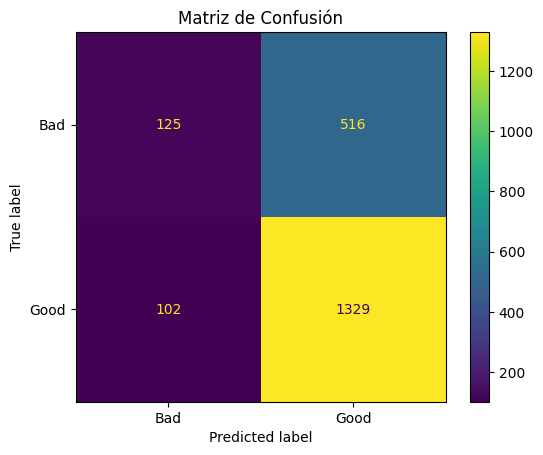

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    clf,
    X_test_transf,
    y_test
)

plt.title("Matriz de Confusión")
plt.show()

##Gridsearch CV

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [4, 8, 12],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    n_jobs=-1
)

grid.fit(X_train_transf, y_train)

print("Mejores parámetros:", grid.best_params_)
print("Mejor score:", grid.best_score_)

Mejores parámetros: {'criterion': 'gini', 'max_depth': 4, 'n_estimators': 100}
Mejor score: 0.6982498549020297


##RandomizedSearch CV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=5,
    cv=3,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_transf, y_train)

print("Mejores parámetros:", random_search.best_params_)
print("Mejor score:", random_search.best_score_)

Mejores parámetros: {'n_estimators': 100, 'max_depth': 12, 'criterion': 'entropy'}
Mejor score: 0.6982498549020297


#Modelos No Supervisados
##KMeans

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans.fit(X_train_transf)

clusters = kmeans.predict(X_test_transf)

print(clusters[:20])

[2 0 2 0 1 0 1 0 0 0 1 0 1 0 0 2 0 1 0 1]


In [ ]:
from collections import Counter

print(Counter(clusters))

Counter({np.int32(0): 1450, np.int32(1): 314, np.int32(2): 308})


##PCA

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)

X_pca = pca.fit_transform(
    X_train_transf.toarray()
)

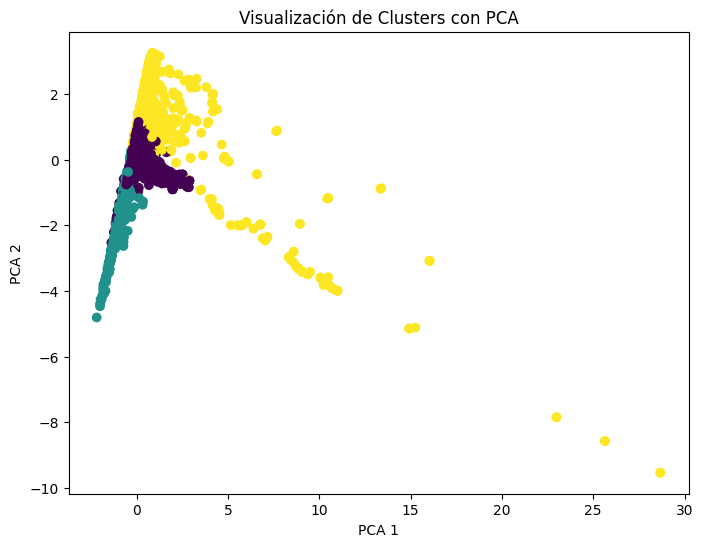

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans.labels_
)

plt.title('Visualización de Clusters con PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

plt.show()

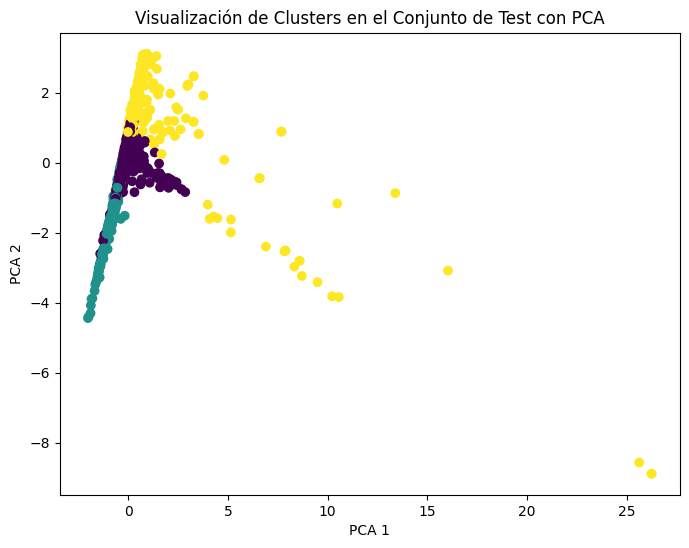

In [ ]:
# 1. Transformar el conjunto de TEST con el PCA ya ajustado al Train
# (Nota: Se usa pca.transform, NO fit_transform para evitar sesgos)
X_test_pca = pca.transform(X_test_transf.toarray())

plt.figure(figsize=(8,6))
# 2. Graficamos el Test con los clusters predichos en el Test ('clusters')
plt.scatter(
    X_test_pca[:,0],
    X_test_pca[:,1],
    c=clusters, # <--- Usar las predicciones del test
    cmap='viridis'
)
plt.title('Visualización de Clusters en el Conjunto de Test con PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

##DBSCAN

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=3,
    min_samples=5
)

db_clusters = dbscan.fit_predict(X_train_transf)

print(db_clusters[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


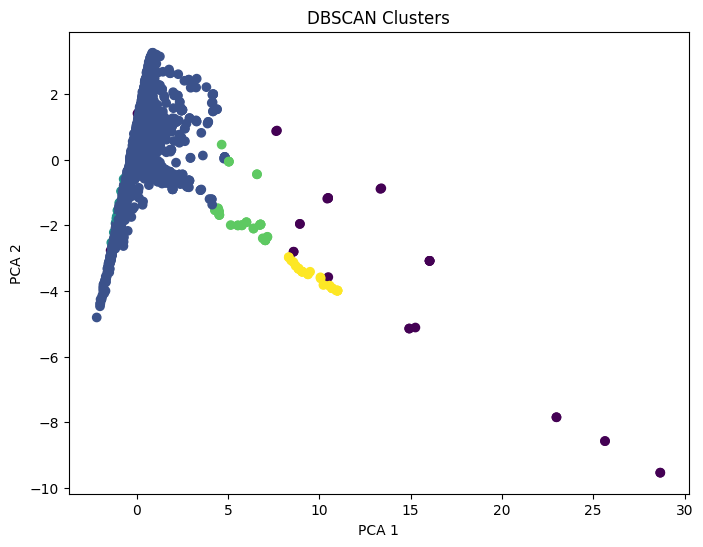

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=db_clusters
)

plt.title('DBSCAN Clusters')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

plt.show()

##Agglomerative Clustering

In [ ]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(
    n_clusters=3
)

agg_clusters = agg.fit_predict(
    X_train_transf.toarray()
)

print(agg_clusters[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
print(Counter(clusters))

Counter({np.int32(0): 1450, np.int32(1): 314, np.int32(2): 308})


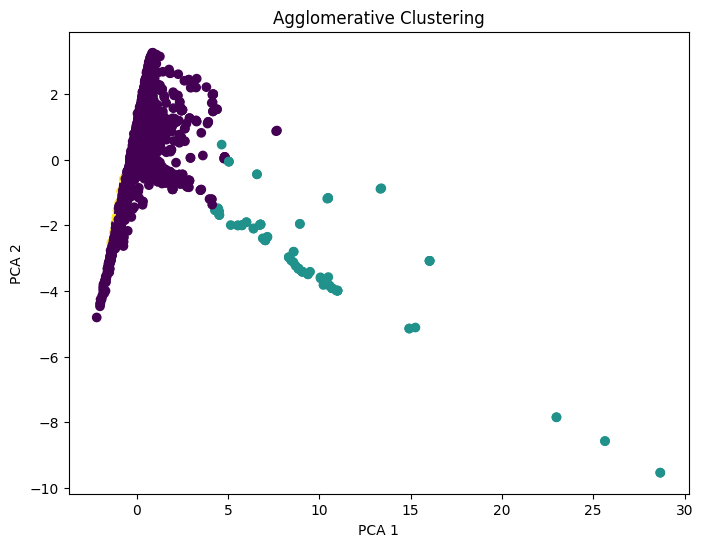

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=agg_clusters
)

plt.title('Agglomerative Clustering')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

plt.show()

In [ ]:
from sklearn import set_config

set_config(display='diagram')

pipeline

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Reviews', 'Size', 'Installs', 'Price',
                                  'Days Last Update']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Category', 'Type', 'Content Rating',
                                  'Genres', 'Current Ver', 'Android Ver'])])

In [ ]:
print(X_train_transf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 91135 stored elements and shape (8285, 2620)>
  Coords	Values
  (0, 0)	-0.15367443003474618
  (0, 1)	1.2870150052297396
  (0, 2)	-0.17575589895653246
  (0, 3)	0.0014683466672132954
  (0, 4)	2.7674677081723993
  (0, 16)	1.0
  (0, 39)	1.0
  (0, 41)	1.0
  (0, 76)	1.0
  (0, 526)	1.0
  (0, 2598)	1.0
  (1, 0)	-0.1536890053123554
  (1, 1)	-0.6071429560268778
  (1, 2)	-0.17576819863159485
  (1, 3)	0.356837407418443
  (1, 4)	2.020947020012422
  (1, 8)	1.0
  (1, 39)	1.0
  (1, 41)	1.0
  (1, 63)	1.0
  (1, 2485)	1.0
  (1, 2591)	1.0
  (2, 0)	-0.119253139291674
  (2, 1)	-0.28747398019767545
  (2, 2)	-0.1633444086662913
  :	:
  (8282, 110)	1.0
  (8282, 2530)	1.0
  (8282, 2619)	1.0
  (8283, 0)	-0.14341225281858946
  (8283, 1)	-0.33518576763486985
  (8283, 2)	-0.11364875184850884
  (8283, 3)	-0.06249808426800805
  (8283, 4)	-0.6549261223447953
  (8283, 15)	1.0
  (8283, 38)	1.0
  (8283, 41)	1.0
  (8283, 102)	1.0
  (8283, 1862)	1.0
  (8283, 261

## Dashboard

In [ ]:
import dash
from dash import dcc, html, Input, Output
import plotly.express as px
import pandas as pd

if 'Installs' in df_clean.columns and df_clean['Installs'].dtype == 'object':
    df_clean['Installs_Numeric'] = df_clean['Installs'].str.replace('+', '').str.replace(',', '')
    df_clean['Installs_Numeric'] = pd.to_numeric(df_clean['Installs_Numeric'], errors='coerce')
else:
    df_clean['Installs_Numeric'] = df_clean['Installs']

def limpiar_tamano_mb(x):
    if pd.isna(x) or not isinstance(x, str): return None
    if 'M' in x: return float(x.replace('M', ''))
    elif 'k' in x: return float(x.replace('k', '')) / 1024
    return None

if 'Size' in df_clean.columns and 'Size_MB' not in df_clean.columns:
    df_clean['Size_MB'] = df_clean['Size'].apply(limpiar_tamano_mb)

app = dash.Dash(__name__)

# Diseño del Dashboard (Interfaz de Usuario)
app.layout = html.Div(style={'fontFamily': 'Segoe UI, Arial, sans-serif', 'padding': '25px', 'backgroundColor': '#f4f6f9'}, children=[
    
    # Encabezado principal
    html.Div([
        html.H1("Google Play Store Apps Dashboard", style={'textAlign': 'center', 'color': '#2c3e50', 'margin': '0', 'fontWeight': 'bold'}),
        html.P("Análisis interactivo de categorías, monetización y métricas técnicas", style={'textAlign': 'center', 'color': '#7f8c8d', 'marginTop': '5px'})
    ], style={'backgroundColor': '#ffffff', 'padding': '20px', 'borderRadius': '8px', 'marginBottom': '20px', 'boxShadow': '0 2px 4px rgba(0,0,0,0.1)'}),
    
    # Barra de Control / Filtro Único
    html.Div([
        html.Label("Selecciona la Clasificación de Contenido (Content Rating):", style={'fontWeight': '600', 'color': '#34495e', 'marginBottom': '8px', 'display': 'block'}),
        dcc.Dropdown(
            id='selector-content-rating',
            options=[{'label': str(i), 'value': str(i)} for i in df_clean['Content Rating'].dropna().unique()],
            value=df_clean['Content Rating'].dropna().unique()[0], # Valor por defecto inicial
            clearable=False,
            style={'width': '100%'}
        )
    ], style={'backgroundColor': '#ffffff', 'padding': '15px', 'borderRadius': '8px', 'marginBottom': '20px', 'boxShadow': '0 2px 4px rgba(0,0,0,0.1)'}),
    
    # Fila de Indicadores Clave (KPIs)
    html.Div(id='tarjetas-kpi', style={'display': 'flex', 'gap': '15px', 'justifyContent': 'space-between', 'marginBottom': '25px'}),
    
    # SECCIÓN 1: Enfoque de Negocio / Gerencial
    html.Div([
        html.H3("📊 Análisis de Negocio & Mercado (Gerencial)", style={'color': '#2c3e50', 'borderBottom': '2px solid #3498db', 'paddingBottom': '5px', 'marginBottom': '15px'}),
        html.Div([
            html.Div([dcc.Graph(id='graph-pie-monetizacion')], style={'width': '49%', 'backgroundColor': '#ffffff', 'padding': '10px', 'borderRadius': '8px', 'boxShadow': '0 2px 4px rgba(0,0,0,0.05)'}),
            html.Div([dcc.Graph(id='graph-bar-categorias')], style={'width': '49%', 'backgroundColor': '#ffffff', 'padding': '10px', 'borderRadius': '8px', 'boxShadow': '0 2px 4px rgba(0,0,0,0.05)'})
        ], style={'display': 'flex', 'justifyContent': 'space-between', 'marginBottom': '25px'})
    ]),
    
    # SECCIÓN 2: Enfoque Técnico / Atributos de App
    html.Div([
        html.H3("⚙️ Análisis Técnico & Performance (Desarrollo)", style={'color': '#2c3e50', 'borderBottom': '2px solid #9b59b6', 'paddingBottom': '5px', 'marginBottom': '15px'}),
        html.Div([
            html.Div([dcc.Graph(id='graph-hist-ratings')], style={'width': '49%', 'backgroundColor': '#ffffff', 'padding': '10px', 'borderRadius': '8px', 'boxShadow': '0 2px 4px rgba(0,0,0,0.05)'}),
            html.Div([dcc.Graph(id='graph-scatter-tamano')], style={'width': '49%', 'backgroundColor': '#ffffff', 'padding': '10px', 'borderRadius': '8px', 'boxShadow': '0 2px 4px rgba(0,0,0,0.05)'})
        ], style={'display': 'flex', 'justifyContent': 'space-between'})
    ])
])

# Callback para gobernar la reactividad de todos los componentes en cascada
@app.callback(
    [Output('tarjetas-kpi', 'children'),
     Output('graph-pie-monetizacion', 'figure'),
     Output('graph-bar-categorias', 'figure'),
     Output('graph-hist-ratings', 'figure'),
     Output('graph-scatter-tamano', 'figure')],
    [Input('selector-content-rating', 'value')]
)
def actualizar_dashboard(rating_seleccionado):
    # Filtrar el dataframe según la selección actual
    df_filtrado = df_clean[df_clean['Content Rating'] == rating_seleccionado]
    
    # PROCESAMIENTO DE KPIs
    total_apps = df_filtrado.shape[0]
    rating_promedio = df_filtrado['Rating'].mean()
    total_installs = df_filtrado['Installs_Numeric'].sum()
    
    apps_pagas = df_filtrado[df_filtrado['Type'] == 'Paid'].shape[0]
    pct_pagas = (apps_pagas / total_apps * 100) if total_apps > 0 else 0
    
    # Estructura visual de los cuadros informativos
    kpis_html = [
        html.Div([html.P("Total de Apps", style={'margin':'0','color':'#7f8c8d','fontSize':'14px'}), html.H2(f"{total_apps:,}", style={'margin':'5px 0 0 0','color':'#2c3e50'})], style={'backgroundColor':'#fff','padding':'15px','borderRadius':'8px','flex':'1','boxShadow':'0 2px 4px rgba(0,0,0,0.05)','textAlign':'center','borderTop':'4px solid #3498db'}),
        html.Div([html.P("Calificación Promedio", style={'margin':'0','color':'#7f8c8d','fontSize':'14px'}), html.H2(f"{rating_promedio:.2f} ⭐" if not pd.isna(rating_promedio) else "N/A", style={'margin':'5px 0 0 0','color':'#2c3e50'})], style={'backgroundColor':'#fff','padding':'15px','borderRadius':'8px','flex':'1','boxShadow':'0 2px 4px rgba(0,0,0,0.05)','textAlign':'center','borderTop':'4px solid #e67e22'}),
        html.Div([html.P("Descargas Estimadas", style={'margin':'0','color':'#7f8c8d','fontSize':'14px'}), html.H2(f"{total_installs:,}", style={'margin':'5px 0 0 0','color':'#2c3e50'})], style={'backgroundColor':'#fff','padding':'15px','borderRadius':'8px','flex':'1','boxShadow':'0 2px 4px rgba(0,0,0,0.05)','textAlign':'center','borderTop':'4px solid #2ecc71'}),
        html.Div([html.P("Proporción de Pago", style={'margin':'0','color':'#7f8c8d','fontSize':'14px'}), html.H2(f"{pct_pagas:.1f}%", style={'margin':'5px 0 0 0','color':'#2c3e50'})], style={'backgroundColor':'#fff','padding':'15px','borderRadius':'8px','flex':'1','boxShadow':'0 2px 4px rgba(0,0,0,0.05)','textAlign':'center','borderTop':'4px solid #e74c3c'})
    ]
    
    # FIGURA 1: Distribución del Modelo de Negocio
    fig_pie = px.pie(
        df_filtrado.dropna(subset=['Type']), 
        names='Type', 
        title="Estrategia de Monetización (Gratis vs Pago)",
        hole=0.4,
        color_discrete_sequence=['#3498db', '#e74c3c']
    )
    fig_pie.update_layout(margin=dict(t=40, b=10, l=10, r=10))
    
    # FIGURA 2: Mercado por Descargas
    df_cat = df_filtrado.groupby('Category')['Installs_Numeric'].sum().reset_index()
    df_cat = df_cat.sort_values(by='Installs_Numeric', ascending=False).head(10)
    
    fig_bar = px.bar(
        df_cat, 
        x='Installs_Numeric', 
        y='Category', 
        orientation='h',
        title="Top 10 Categorías con Mayor Volumen de Mercado",
        labels={'Installs_Numeric': 'Installs Totales', 'Category': 'Categoría'},
        color_discrete_sequence=['#2ecc71']
    )
    fig_bar.update_layout(yaxis={'categoryorder': 'total ascending'}, margin=dict(t=40, b=40, l=10, r=10))
    
    # FIGURA 3: Distribución de Ratings
    fig_hist = px.histogram(
        df_filtrado.dropna(subset=['Rating']), 
        x='Rating', 
        nbins=20, 
        title="Histograma de Distribución de Puntuaciones (Ratings)",
        color_discrete_sequence=['#9b59b6']
    )
    fig_hist.update_layout(margin=dict(t=40, b=40, l=10, r=10), xaxis_title="Calificación", yaxis_title="Cantidad de Apps")
    
    # FIGURA 4:  Distribución de Ratings por Tipo de Monetización
    fig_scatter = px.box(
        df_filtrado.dropna(subset=['Type', 'Rating']),
        x='Type',
        y='Rating',
        title="Distribución y Mediana de Ratings por Tipo de App",
        labels={'Type': 'Tipo de App', 'Rating': 'Calificación (Rating)'},
        color='Type',
        color_discrete_sequence=['#16a085', '#e67e22']
    )
    fig_scatter.update_layout(margin=dict(t=40, b=40, l=10, r=10))
    fig_scatter.update_layout(margin=dict(t=40, b=40, l=10, r=10))
    
    
    return kpis_html, fig_pie, fig_bar, fig_hist, fig_scatter

app.run(mode='inline', port=8030)